Le but ici est seulement de :

- Vérifier que les fichiers sont trouvés ; </br>
- Charger toutes les tables ; </br>
- Afficher leur structure ; </br>
- Commencer à comprendre le grain ; </br>
- Avoir une idée du taux de remplissage.

### I- Imports

In [1]:
# import des librairies nécessaires
import sys 
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

# Ajout de la racine du projet au chemin d'importation
PROJET_ROOT = Path().resolve().parents[0] # Chemin vers la racine du projet (path pour accéder aux modules src, resolve le chemin à partir du script actuel, parents[0] remonte d'un niveau pour atteindre la racine)
if PROJET_ROOT not in sys.path: # Ajout de la racine du projet au chemin d'importation si ce n'est pas déjà fait
    sys.path.append(str(PROJET_ROOT))

# Import des modules de chargement de données et de configuration
from src.config import RAW_DIR
from src.data_loader import (get_csv_files, load_all_tables, build_overview_table)

Dossier général du projet: /Users/bervie/Documents/RAS/SCHOOL/Data Science Auto/Trainning/Brazilian E-Commerce (Olist)
Chemin général des données: /Users/bervie/Documents/RAS/SCHOOL/Data Science Auto/Trainning/Brazilian E-Commerce (Olist)/data
Dossier des données brutes: /Users/bervie/Documents/RAS/SCHOOL/Data Science Auto/Trainning/Brazilian E-Commerce (Olist)/data/raw
Dossier des données intermédiaires: /Users/bervie/Documents/RAS/SCHOOL/Data Science Auto/Trainning/Brazilian E-Commerce (Olist)/data/iterim
Dossier des données traitées: /Users/bervie/Documents/RAS/SCHOOL/Data Science Auto/Trainning/Brazilian E-Commerce (Olist)/data/processed
Dossier des notebooks: /Users/bervie/Documents/RAS/SCHOOL/Data Science Auto/Trainning/Brazilian E-Commerce (Olist)/notebooks
Dossier des rapports: /Users/bervie/Documents/RAS/SCHOOL/Data Science Auto/Trainning/Brazilian E-Commerce (Olist)/REPORTS
Dossier des figures: /Users/bervie/Documents/RAS/SCHOOL/Data Science Auto/Trainning/Brazilian E-Commerc

In [2]:
# Vérification de la présence des fichiers CSV dans le répertoire RAW_DIR
csv_files = get_csv_files()

print("Dossier raw : ", RAW_DIR)
print("Nombre de fichiers csv trouvés : ", len(csv_files))

for file in csv_files:
    print("-", file.name)

Dossier raw :  /Users/bervie/Documents/RAS/SCHOOL/Data Science Auto/Trainning/Brazilian E-Commerce (Olist)/data/raw
Nombre de fichiers csv trouvés :  9
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_items_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_orders_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- product_category_name_translation.csv


##### Notes : Nous avons bien tout nos fichiers csv.

### II- Charger les tables

In [3]:
tables = load_all_tables()
list(tables.keys())

['customers',
 'geolocation',
 'order_items',
 'order_payments',
 'order_reviews',
 'orders',
 'products',
 'sellers',
 'product_category_name_translation']

In [4]:
# Vue d'ensemble
overview = build_overview_table(tables)
overview

,n_rows,n_cols,missing_cells,duplicate_rows,fill_rate
table,,,,,
geolocation,1000163,5,0,261831,100.00
order_items,112650,7,0,0,100.00
order_payments,103886,5,0,0,100.00
customers,99441,5,0,0,100.00
orders,99441,8,4908,0,99.38
order_reviews,99224,7,145903,0,78.99
products,32951,9,2448,0,99.17
sellers,3095,4,0,0,100.00
product_category_name_translation,71,2,0,0,100.00


In [5]:
# Vue sur les premieres lignes de chaque table
for name, df in tables.items(): # Parcours de chaque table chargée (.items() retourne les paires clé-valeur du dictionnaire tables, où name est le nom de la table et df est le DataFrame correspondant)
    print(f"\n===== {name.upper()} =====\n")
    display(df.head())


===== CUSTOMERS =====



,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



===== GEOLOCATION =====



,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



===== ORDER_ITEMS =====



...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



===== SELLERS =====



,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



===== PRODUCT_CATEGORY_NAME_TRANSLATION =====



,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



===== ORDER_REVIEWS =====

Taux de remplissage : 78.99%


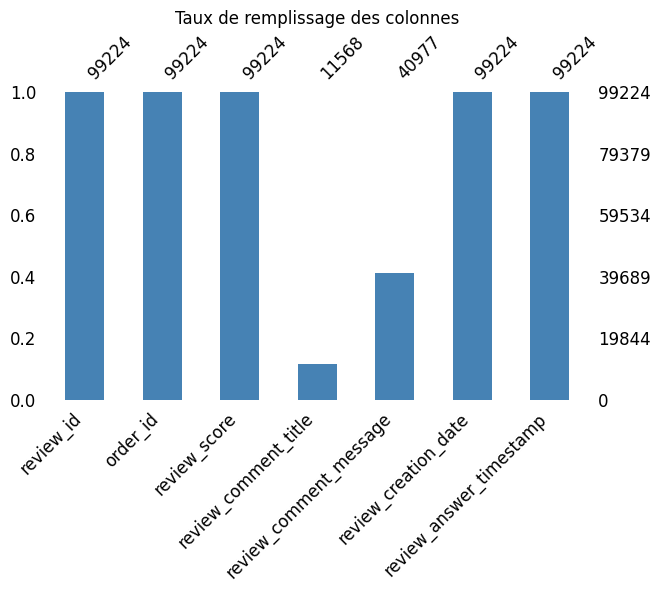


===== ORDERS =====

Taux de remplissage : 99.38%


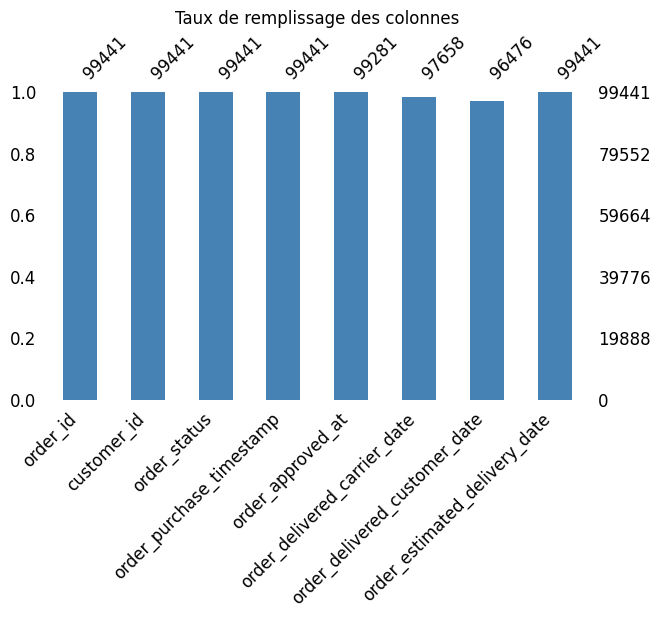


===== PRODUCTS =====

Taux de remplissage : 99.17%


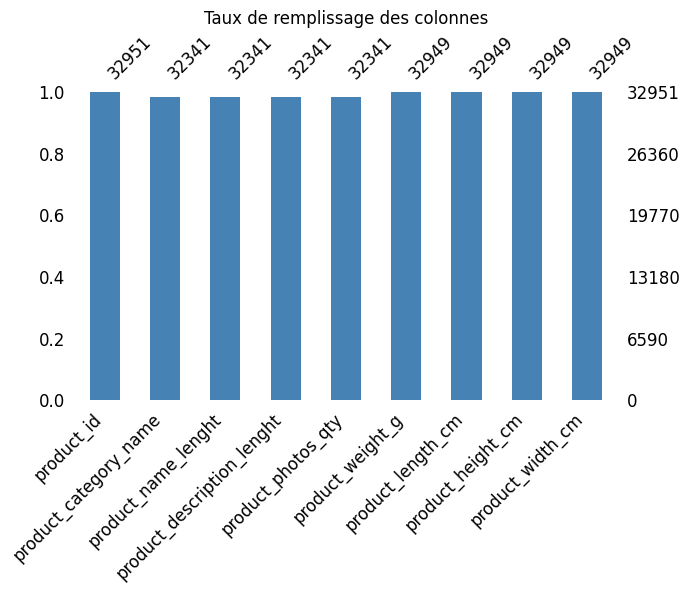

In [6]:
# Visualisation du taux de remplissage des colonnes des tables avec des colonnes manquantes
for name, df in tables.items(): # Parcours de chaque table chargée (.items() retourne les paires clé-valeur du dictionnaire tables, où name est le nom de la table et df est le DataFrame correspondant)
    if overview.loc[name, "fill_rate"] < 100:
        print(f"\n===== {name.upper()} =====\n")
        print(f"Taux de remplissage : {overview.loc[name, 'fill_rate']}%")
        msno.bar(df, figsize=(7, 4), color='steelblue', fontsize=12) 
        plt.title(f"Taux de remplissage des colonnes")
        plt.show()

##### Notes :
Les tables ont globalement un taux de remplissage assez élevé, trois tables ont un taux de remplissage inférieur à 100% : <br/> "olist_order_reviews_dataset", "olist_customers_dataset" et "olist_geolocation_dataset". <br/> <br/>
Trois tables ont des colonnes avec des valeurs manquantes ("ORDER_REVIEWS", "ORDERS", "PRODUCTS"), mais seulement une seule tables à un taux inférieur à 80% : <br/> "ORDER_REVIEWS" avec un taux de remplissage de 78.99%.

Nous pouvons passer à l'EDA (Exploratory Data Analysis) pour mieux comprendre les données et identifier les tendances, les anomalies et les relations entre les variables.

